# 00 Project folder setup

CSE 4889 Machine Learning: Explainable Multi-Label Hate Speech Detection in Transliterated Bangla

We run this notebook once at the start. It creates the project folders in our shared Google Drive, saves the library versions we are using, and starts a list of all the figures and tables we save for the report.

## Mount Google Drive

Colab deletes its local files when the session ends, so we save everything to Drive instead.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Project path and seed

All notebooks use the same project folder path. We also fix the random seed to 42 so the results can be repeated.

If the folder was shared with you, first add a shortcut to it in My Drive, otherwise this path will not be found.

In [2]:
import os
import random
import numpy as np

BASE = '/content/drive/MyDrive/ML_Project'
SEED = 42
NOTEBOOK_NAME = '00_setup_drive_folders.ipynb'

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

assert os.path.isdir(BASE), (
    f'{BASE} not found. Check the folder name in Drive, or add a shortcut to My Drive (see the note above).'
)
print('Project root:', BASE)

Project root: /content/drive/MyDrive/ML_Project


## Create the folders

Notebooks, data, model checkpoints, results and the report each get their own folder. Running this again is safe, folders that already exist are not touched.

In [3]:
folders = [
    'notebooks',
    'src/explainability',
    'src/evaluation',
    'src/augmentation',
    'data/raw',
    'data/processed',
    'data/banth_xplain',
    'results/model_checkpoints',
    'results/evaluation_reports',
    'results/figures',
    'results/tables',
    'report/figures',
]

for folder in folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print(f'{len(folders)} folder paths ready under {BASE}')

12 folder paths ready under /content/drive/MyDrive/ML_Project


## Check that we can write to the folders

We write and delete a small test file in each folder. If someone only has view access to the shared folder, we find out here and not in the middle of training.

In [4]:
problems = []
for folder in folders:
    path = os.path.join(BASE, folder)
    probe = os.path.join(path, '.write_test')
    try:
        with open(probe, 'w') as f:
            f.write('ok')
        os.remove(probe)
    except OSError as e:
        problems.append((folder, str(e)))

if problems:
    for folder, err in problems:
        print('NOT WRITABLE:', folder, '->', err)
else:
    print(f'All {len(folders)} folders exist and are writable.')

All 12 folders exist and are writable.


## Save library versions

Different library versions can give slightly different results, so we save the Python, library and GPU details in environment.txt. Libraries we install later (like lime) show as not installed here.

In [5]:
import sys
import platform
from datetime import datetime
from importlib.metadata import version, PackageNotFoundError

packages = ['torch', 'transformers', 'datasets', 'pandas', 'numpy', 'scikit-learn',
            'matplotlib', 'lime', 'shap', 'gradio']

lines = [
    f'Recorded: {datetime.now().isoformat(timespec="seconds")}',
    f'Notebook: {NOTEBOOK_NAME}',
    f'Seed: {SEED}',
    f'Python: {sys.version.split()[0]}',
    f'Platform: {platform.platform()}',
]

try:
    import torch
    gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none (CPU runtime)'
except ImportError:
    gpu = 'unknown (torch not installed)'
lines.append(f'GPU: {gpu}')

lines.append('')
lines.append('Library versions:')
for pkg in packages:
    try:
        lines.append(f'  {pkg}=={version(pkg)}')
    except PackageNotFoundError:
        lines.append(f'  {pkg}: not installed')

env_path = os.path.join(BASE, 'results', 'evaluation_reports', 'environment.txt')
with open(env_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines) + '\n')

print('\n'.join(lines))
print('\nSaved:', env_path)

Recorded: 2026-09-28T06:11:44
Notebook: 00_setup_drive_folders.ipynb
Seed: 42
Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
GPU: none (CPU runtime)

Library versions:
  torch==2.11.0+cpu
  transformers==5.16.1
  datasets==4.8.5
  pandas==2.2.3
  numpy==2.1.3
  scikit-learn==1.6.1
  matplotlib==3.10.0
  lime: not installed
  shap==0.52.0
  gradio==6.26.0

Saved: /content/drive/MyDrive/ML_Project/results/evaluation_reports/environment.txt


## Start the results list

ASSETS.md is a list of every figure and table we save, with the report section it belongs to and its caption. We write the report from this list. If the file already exists we leave it as it is.

In [6]:
ASSETS_PATH = os.path.join(BASE, 'results', 'ASSETS.md')

ASSETS_HEADER = '''# Asset Registry

List of every figure, table and results file saved for the report.
Paths are relative to the results folder.

ID convention: F = figure, T = table, M = metrics/log file. Captions use Fig. X / TABLE X as placeholders;
final numbers are assigned by order of appearance in report/main.tex.

| Asset ID | File name | What it shows | Notebook | Report section | Caption (IEEE style) |
|---|---|---|---|---|---|
'''

if not os.path.exists(ASSETS_PATH):
    with open(ASSETS_PATH, 'w', encoding='utf-8') as f:
        f.write(ASSETS_HEADER)
    print('Created', ASSETS_PATH)
else:
    print('Already exists, left unchanged:', ASSETS_PATH)

Created /content/drive/MyDrive/ML_Project/results/ASSETS.md


## Function to add a row to the list

This adds one row to ASSETS.md. If a notebook is run again, the old row for the same file is replaced instead of added twice.

In [7]:
def register_asset(asset_id, file_name, what, notebook, section, caption):
    row = f'| {asset_id} | {file_name} | {what} | {notebook} | {section} | {caption} |'
    with open(ASSETS_PATH, encoding='utf-8') as f:
        lines = f.read().splitlines()
    lines = [l for l in lines if not l.startswith(f'| {asset_id} |')]
    lines.append(row)
    with open(ASSETS_PATH, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    print('Registered', asset_id, '->', file_name)

register_asset(
    'M01', 'evaluation_reports/environment.txt',
    'Python, library versions, GPU, and seed at setup time',
    NOTEBOOK_NAME, 'IV. Methodology (training setup)',
    'Not a figure; source for the software rows of the training setup table.'
)

Registered M01 -> evaluation_reports/environment.txt


## Picture of the folder structure

We draw the folder tree from the real Drive folders and save it as a 300 dpi image. Checkpoint files are left out because their names are long and not useful to show. A text copy is saved too.

ML_Project/
├── data/
│   ├── banth_xplain/
│   ├── processed/
│   └── raw/
├── notebooks/
│   └── 00_setup_drive_folders.ipynb
├── report/
│   └── figures/
├── results/
│   ├── evaluation_reports/
│   │   └── environment.txt
│   ├── figures/
│   ├── model_checkpoints/
│   ├── tables/
│   └── ASSETS.md
├── src/
│   ├── augmentation/
│   ├── evaluation/
│   └── explainability/
└── HateSpeech_Full_Project.ipynb


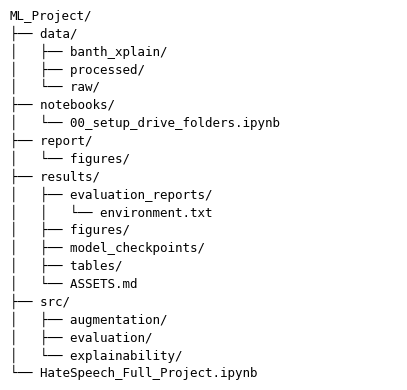

Saved: /content/drive/MyDrive/ML_Project/results/figures/fig_01_folder_tree.png
Saved: /content/drive/MyDrive/ML_Project/results/evaluation_reports/folder_tree.txt


In [8]:
import matplotlib.pyplot as plt

def build_tree(root, max_depth=3):
    lines = [os.path.basename(root) + '/']

    def walk(path, prefix, depth):
        if depth > max_depth:
            return
        entries = sorted(e for e in os.listdir(path) if not e.startswith('.'))
        dirs = [e for e in entries if os.path.isdir(os.path.join(path, e))]
        files = [e for e in entries if e not in dirs]
        if os.path.basename(path) == 'model_checkpoints':
            dirs, files = [], []
        items = dirs + files
        for i, name in enumerate(items):
            last = (i == len(items) - 1)
            lines.append(prefix + ('└── ' if last else '├── ') + name + ('/' if name in dirs else ''))
            if name in dirs:
                walk(os.path.join(path, name), prefix + ('    ' if last else '│   '), depth + 1)

    walk(root, '', 1)
    return lines

tree_lines = build_tree(BASE)
print('\n'.join(tree_lines))

tree_txt_path = os.path.join(BASE, 'results', 'evaluation_reports', 'folder_tree.txt')
with open(tree_txt_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(tree_lines) + '\n')

fig_height = 0.2 * len(tree_lines) + 0.3
fig, ax = plt.subplots(figsize=(5, fig_height))
ax.axis('off')
ax.text(0, 1, '\n'.join(tree_lines), family='DejaVu Sans Mono', fontsize=9,
        va='top', ha='left', transform=ax.transAxes)

fig_path = os.path.join(BASE, 'results', 'figures', 'fig_01_folder_tree.png')
fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', fig_path)
print('Saved:', tree_txt_path)

## Add the figure to the list

In [9]:
register_asset(
    'F01', 'figures/fig_01_folder_tree.png',
    'Project folder layout on the shared Google Drive (3 levels, checkpoints hidden)',
    NOTEBOOK_NAME, 'IV. Methodology (optional) / show slides',
    'Fig. X. Folder structure of the shared project directory used for notebooks, data, model checkpoints, and saved results.'
)
register_asset(
    'M02', 'evaluation_reports/folder_tree.txt',
    'Plain-text version of the folder tree in F01',
    NOTEBOOK_NAME, 'Not used directly',
    'Not a figure; text copy of F01.'
)

with open(ASSETS_PATH, encoding='utf-8') as f:
    print(f.read())

Registered F01 -> figures/fig_01_folder_tree.png
Registered M02 -> evaluation_reports/folder_tree.txt
# Asset Registry

Every figure, table, metric, and log file that may appear in the report (details.md Section 15).
The report is written only from files listed here. Paths are relative to `results/`.

ID convention: F = figure, T = table, M = metrics/log file. Captions use Fig. X / TABLE X as placeholders;
final numbers are assigned by order of appearance in report/main.tex.

| Asset ID | File name | What it shows | Notebook | Report section | Caption (IEEE style) |
|---|---|---|---|---|---|
| M01 | evaluation_reports/environment.txt | Python, library versions, GPU, and seed at setup time | 00_setup_drive_folders.ipynb | IV. Methodology (training setup) | Not a figure; source for the software rows of the training setup table. |
| F01 | figures/fig_01_folder_tree.png | Project folder layout on the shared Google Drive (3 levels, checkpoints hidden) | 00_setup_drive_folders.ipynb | IV. Me

## Summary

We created the project folders, checked write access, saved the library versions and started the results list. The folder tree image is in results/figures/fig_01_folder_tree.png.

After running this, share the ML_Project folder with the team as Editor. The next notebook, 01_data_exploration, uses these folders.

## Remember this

- What we did: made the shared project folders on Drive and saved our library versions.
- Why: Colab loses its files when it disconnects, so everything has to be saved to Drive.
- Key number: 12 folders, and seed 42 for the whole project.